# 🔋 BatteryIQ — Combined Dataset EDA
**Chapter 4 — Data Engineering**

Cross-dataset analysis of all 3 sources combined:
- NASA: 34 cells, NMC chemistry
- Stanford: 140 cells, LFP chemistry  
- CALCE: 15 cells, LiCoO2 chemistry
- **Total: 189 cells, 134,938 cycles**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

SOURCE_COLORS = {
    'nasa'    : '#378ADD',
    'stanford': '#1D9E75',
    'calce'   : '#EF9F27'
}
CHEM_COLORS = {
    'NMC': '#378ADD',
    'LFP': '#1D9E75',
    'CS2': '#EF9F27',
    'CX2': '#EF4444'
}

ROOT    = Path.cwd().parent
FEAT    = ROOT / 'data' / 'features'
FIG_DIR = ROOT / 'memoire' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(FEAT / 'combined_soh_clean.csv')
print(f'Shape        : {df.shape}')
print(f'Sources      : {df["source"].value_counts().to_dict()}')
print(f'Chemistries  : {df["chemistry"].value_counts().to_dict()}')
print(f'Total cells  : {df["cell_id"].nunique()}')
df.head(3)

Shape        : (134938, 13)
Sources      : {'stanford': 114688, 'calce': 18379, 'nasa': 1871}
Chemistries  : {'LFP': 114688, 'CX2': 12412, 'CS2': 5967, 'NMC': 1871}
Total cells  : 189


,cell_id,source,chemistry,cycle_number,cycle_capacity_ah,nominal_capacity_ah,soh_pct,rul_cycles,status,avg_voltage_v,avg_current_a,avg_temp_c,internal_resistance
0,B0005,nasa,NMC,1,1.632735,1.5571,104.86,0,healthy,3.530913,-1.857820,32.455493,NaN
1,B0005,nasa,NMC,2,1.627753,1.5571,104.54,0,healthy,3.528723,-1.857216,32.500172,NaN
2,B0005,nasa,NMC,3,1.622125,1.5571,104.18,0,healthy,3.526255,-1.856834,32.501003,NaN


## 1. Cross-Dataset Overview

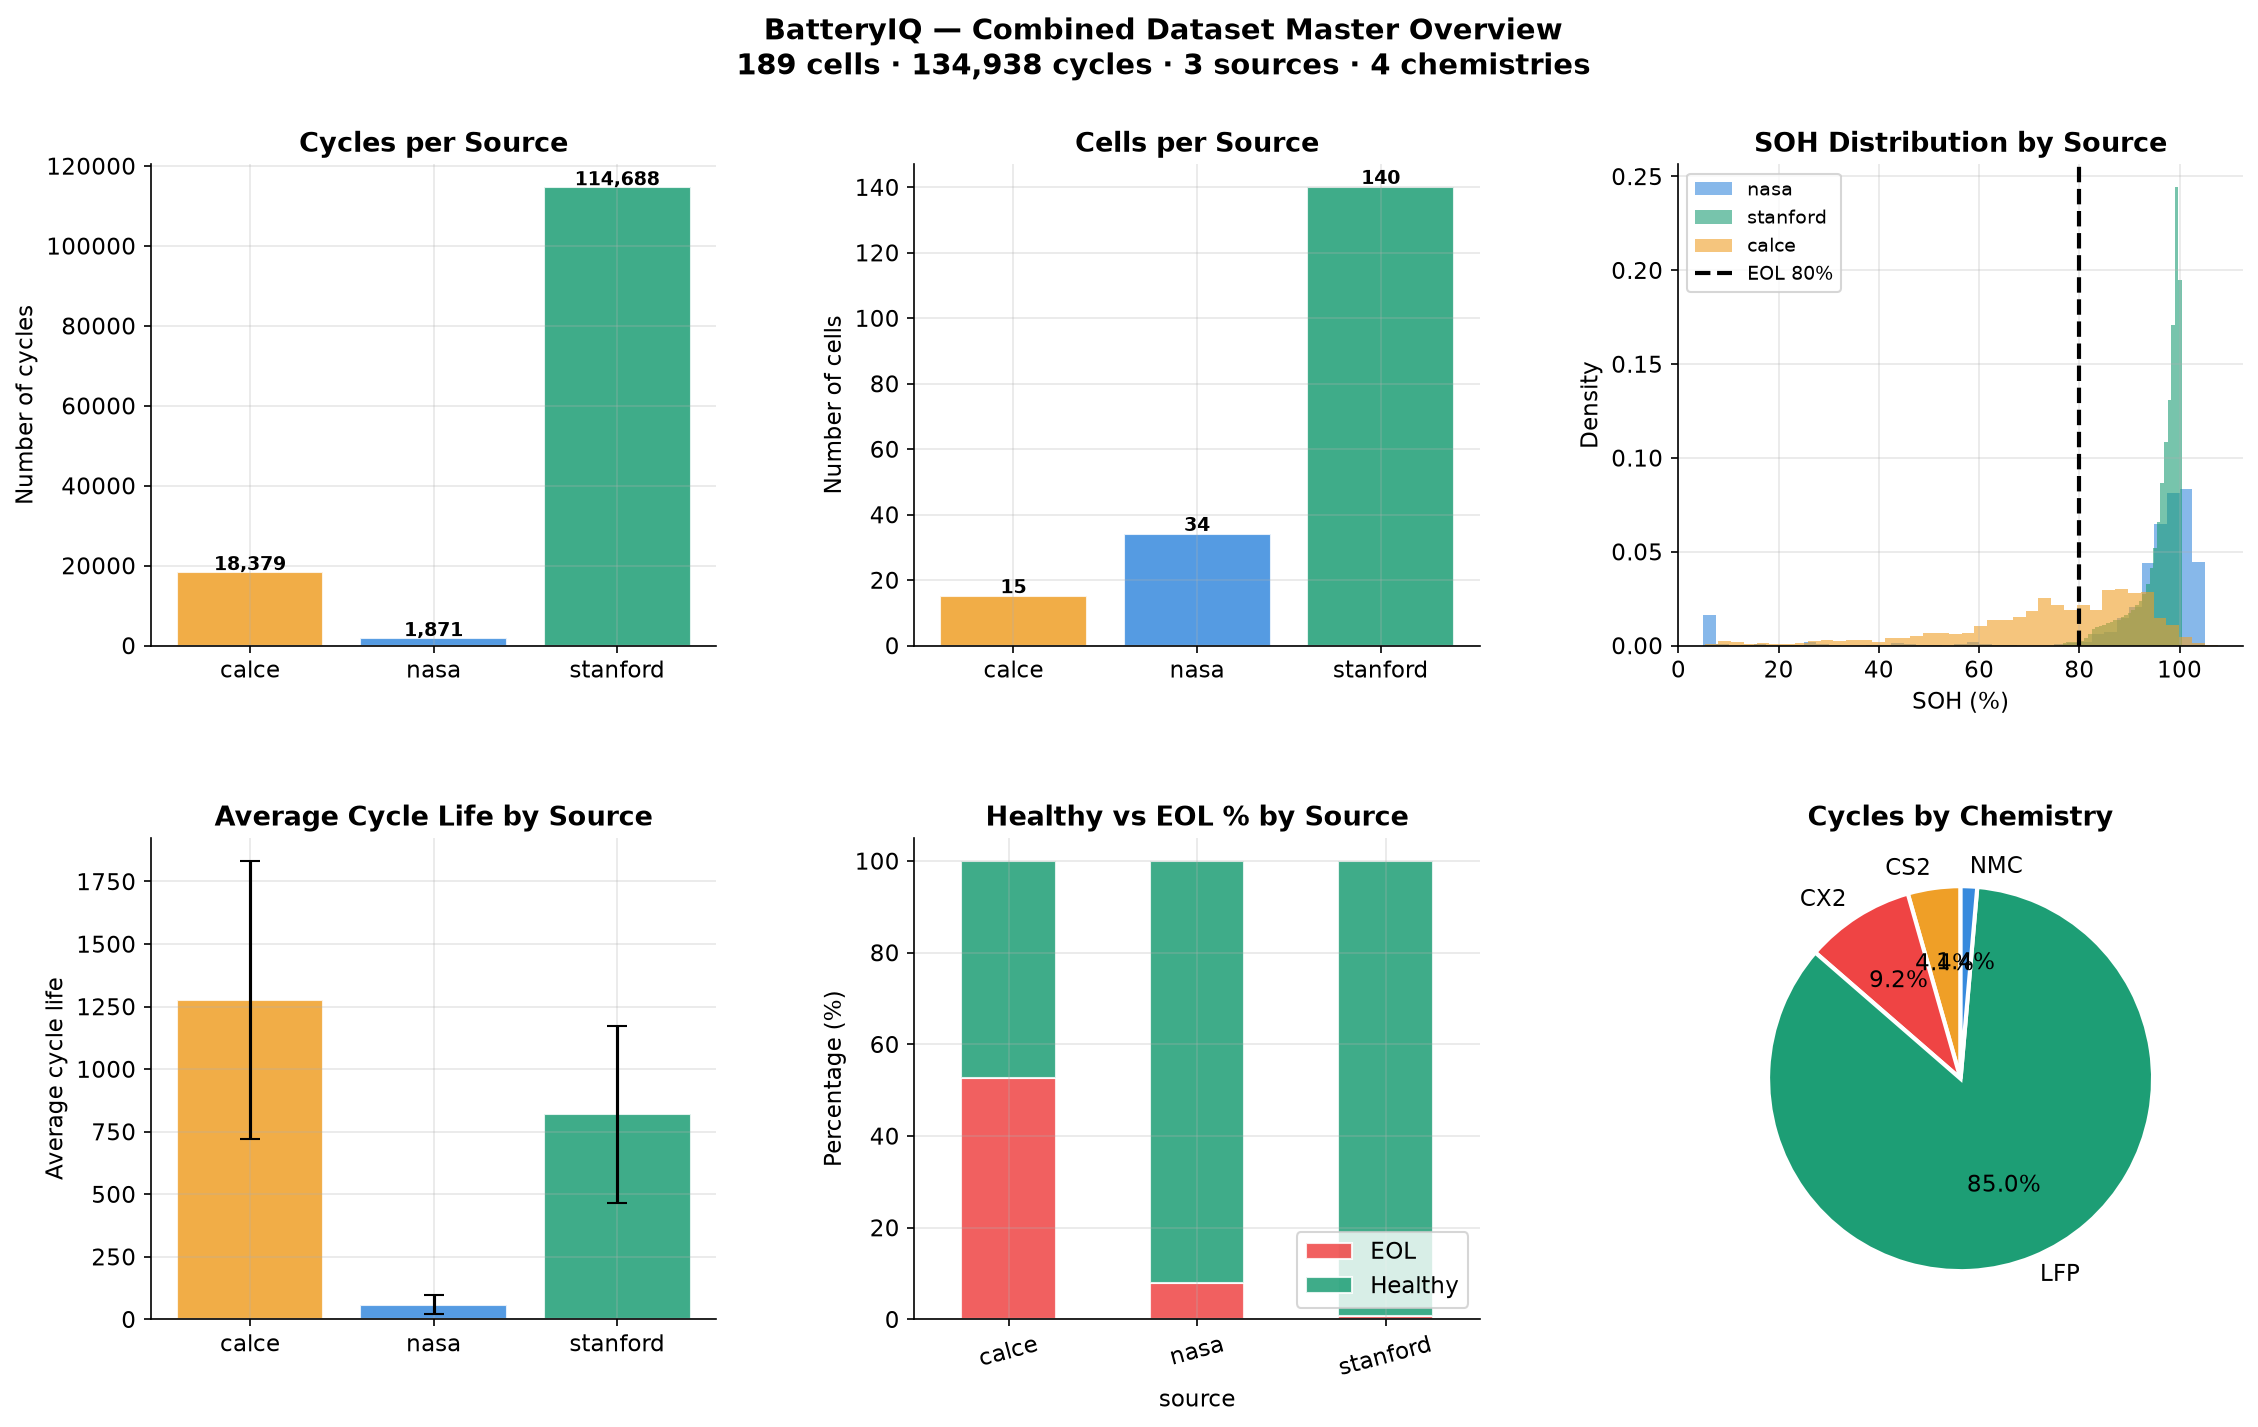

✅ Saved → fig23_combined_master_overview.png


In [2]:
# Fig 1 — Master overview
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1a. Cycles per source (bar)
ax1 = fig.add_subplot(gs[0, 0])
src_counts = df.groupby('source').size()
bars = ax1.bar(src_counts.index, src_counts.values,
               color=[SOURCE_COLORS[s] for s in src_counts.index],
               alpha=0.85, edgecolor='white')
for bar, val in zip(bars, src_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,}', ha='center', fontsize=9, fontweight='bold')
ax1.set_ylabel('Number of cycles')
ax1.set_title('Cycles per Source', fontweight='bold')

# 1b. Cells per source
ax2 = fig.add_subplot(gs[0, 1])
cell_counts = df.groupby('source')['cell_id'].nunique()
bars2 = ax2.bar(cell_counts.index, cell_counts.values,
                color=[SOURCE_COLORS[s] for s in cell_counts.index],
                alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, cell_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=9, fontweight='bold')
ax2.set_ylabel('Number of cells')
ax2.set_title('Cells per Source', fontweight='bold')

# 1c. SOH distribution by source
ax3 = fig.add_subplot(gs[0, 2])
for src, color in SOURCE_COLORS.items():
    data = df[df['source'] == src]['soh_pct']
    ax3.hist(data, bins=40, alpha=0.6, color=color,
             edgecolor='none', label=src, density=True)
ax3.axvline(80, color='black', linestyle='--', linewidth=2, label='EOL 80%')
ax3.set_xlabel('SOH (%)')
ax3.set_ylabel('Density')
ax3.set_title('SOH Distribution by Source', fontweight='bold')
ax3.legend(fontsize=9)

# 1d. Average cycle life by source
ax4 = fig.add_subplot(gs[1, 0])
life_by_src = df.groupby(['source','cell_id'])['cycle_number'].max().reset_index()
life_by_src = life_by_src.groupby('source')['cycle_number'].agg(['mean','std'])
ax4.bar(life_by_src.index, life_by_src['mean'],
        color=[SOURCE_COLORS[s] for s in life_by_src.index],
        alpha=0.85, edgecolor='white',
        yerr=life_by_src['std'], capsize=5)
ax4.set_ylabel('Average cycle life')
ax4.set_title('Average Cycle Life by Source', fontweight='bold')

# 1e. Status distribution
ax5 = fig.add_subplot(gs[1, 1])
status_src = df.groupby(['source','status']).size().unstack(fill_value=0)
status_src_pct = status_src.div(status_src.sum(axis=1), axis=0) * 100
status_src_pct.plot(kind='bar', ax=ax5, stacked=True,
                    color=['#EF4444','#1D9E75'],
                    alpha=0.85, edgecolor='white')
ax5.set_ylabel('Percentage (%)')
ax5.set_title('Healthy vs EOL % by Source', fontweight='bold')
ax5.tick_params(axis='x', rotation=15)
ax5.legend(['EOL','Healthy'], loc='lower right')

# 1f. Chemistry breakdown
ax6 = fig.add_subplot(gs[1, 2])
chem_counts = df.groupby('chemistry').size()
wedge_colors = [CHEM_COLORS.get(c,'#888') for c in chem_counts.index]
ax6.pie(chem_counts.values, labels=chem_counts.index,
        colors=wedge_colors, autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax6.set_title('Cycles by Chemistry', fontweight='bold')

plt.suptitle('BatteryIQ — Combined Dataset Master Overview\n189 cells · 134,938 cycles · 3 sources · 4 chemistries',
             fontsize=14, fontweight='bold')
plt.savefig(FIG_DIR / 'fig23_combined_master_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → fig23_combined_master_overview.png')

## 2. Cross-Dataset SOH Comparison

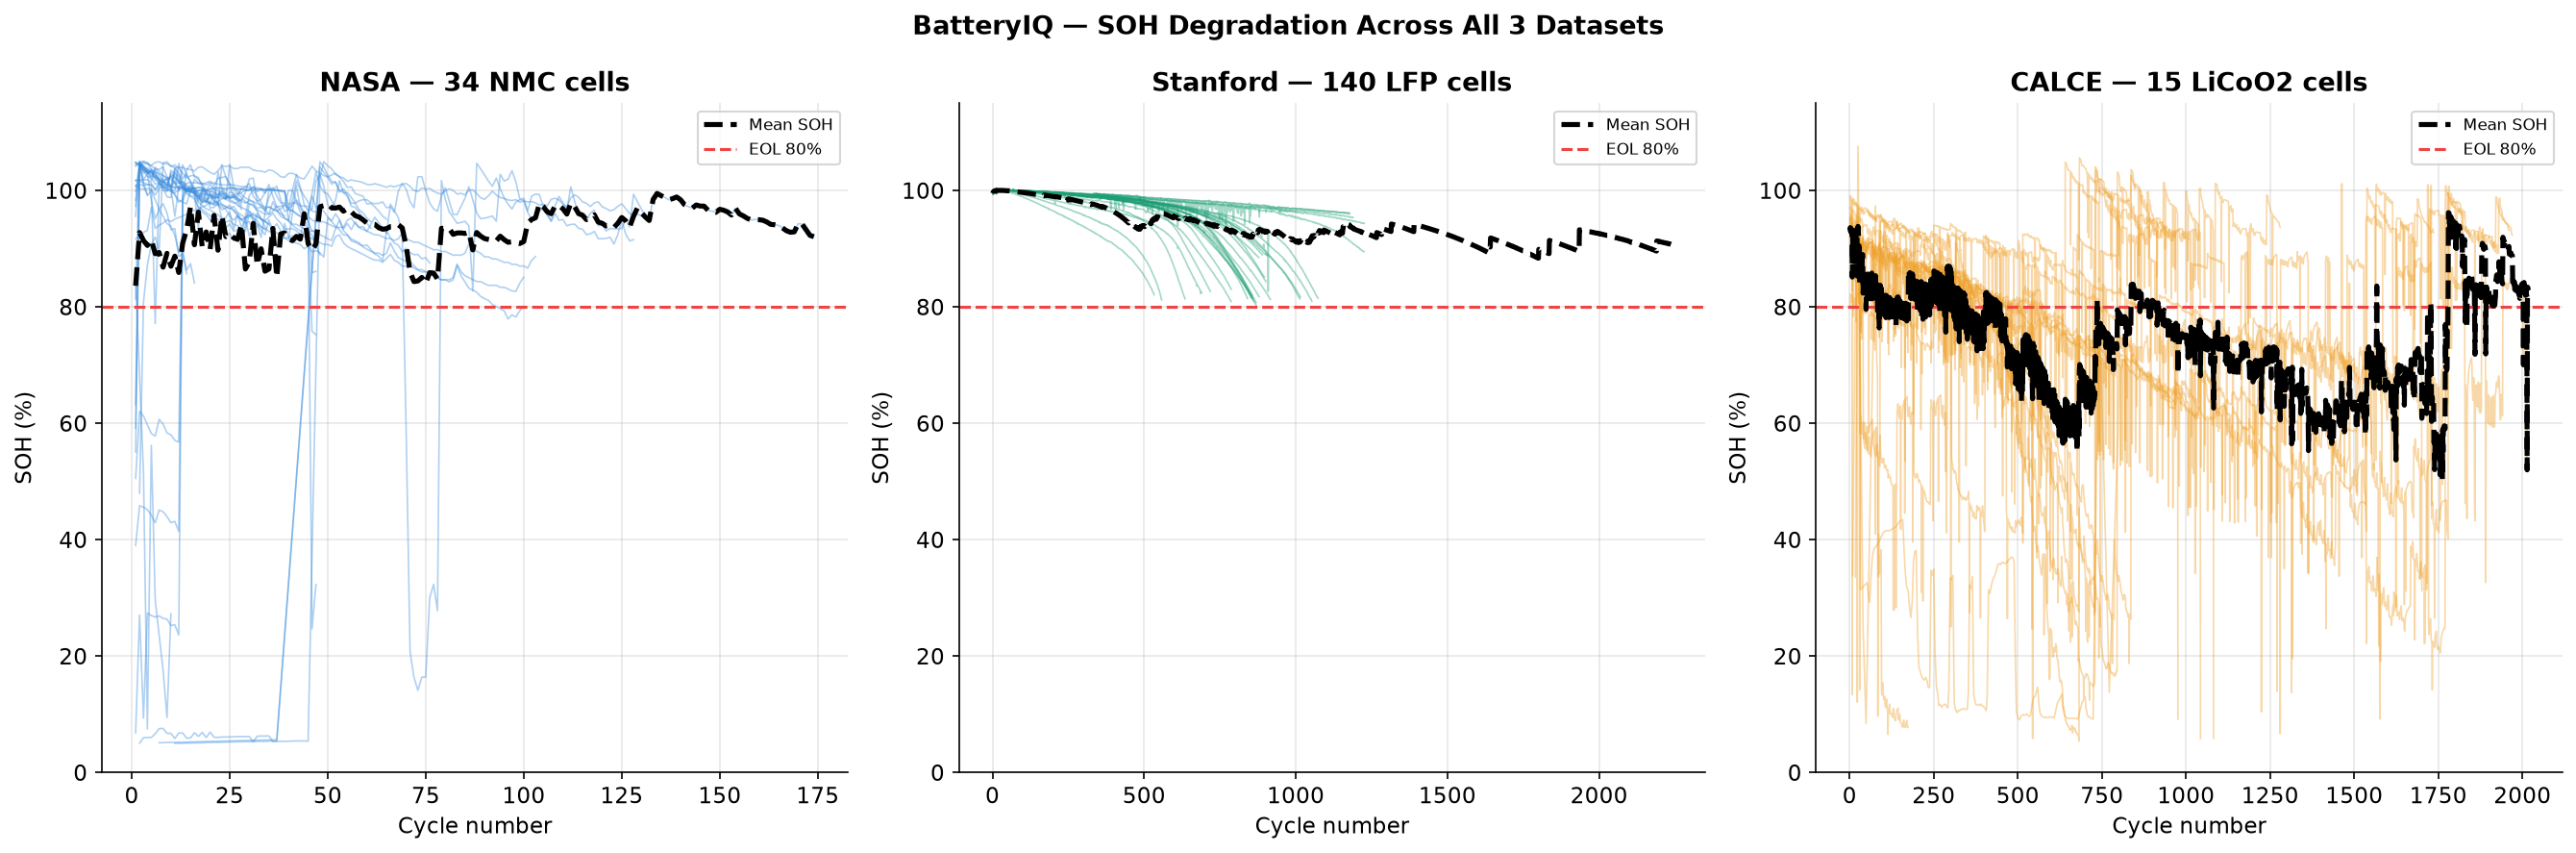

✅ Saved → fig24_combined_soh_comparison.png


In [3]:
# Fig 2 — SOH degradation comparison across sources
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = plt.cm.tab20(np.linspace(0, 1, 20))

for ax, (src, title) in zip(axes, [
    ('nasa',     'NASA — 34 NMC cells'),
    ('stanford', 'Stanford — 140 LFP cells'),
    ('calce',    'CALCE — 15 LiCoO2 cells')
]):
    src_df = df[df['source'] == src]
    cells  = sorted(src_df['cell_id'].unique())
    color  = SOURCE_COLORS[src]

    for i, cell in enumerate(cells[:30]):
        cdf = src_df[src_df['cell_id'] == cell].sort_values('cycle_number')
        ax.plot(cdf['cycle_number'], cdf['soh_pct'],
                linewidth=0.8, alpha=0.4, color=color)

    # Mean SOH trajectory
    mean_soh = src_df.groupby('cycle_number')['soh_pct'].mean()
    ax.plot(mean_soh.index, mean_soh.values,
            color='black', linewidth=2.5,
            linestyle='--', label='Mean SOH', zorder=5)

    ax.axhline(80, color='#EF4444', linestyle='--',
               linewidth=1.5, label='EOL 80%')
    ax.set_xlabel('Cycle number')
    ax.set_ylabel('SOH (%)')
    ax.set_ylim(0, 115)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('BatteryIQ — SOH Degradation Across All 3 Datasets',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig24_combined_soh_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → fig24_combined_soh_comparison.png')

## 3. Cross-Chemistry Analysis

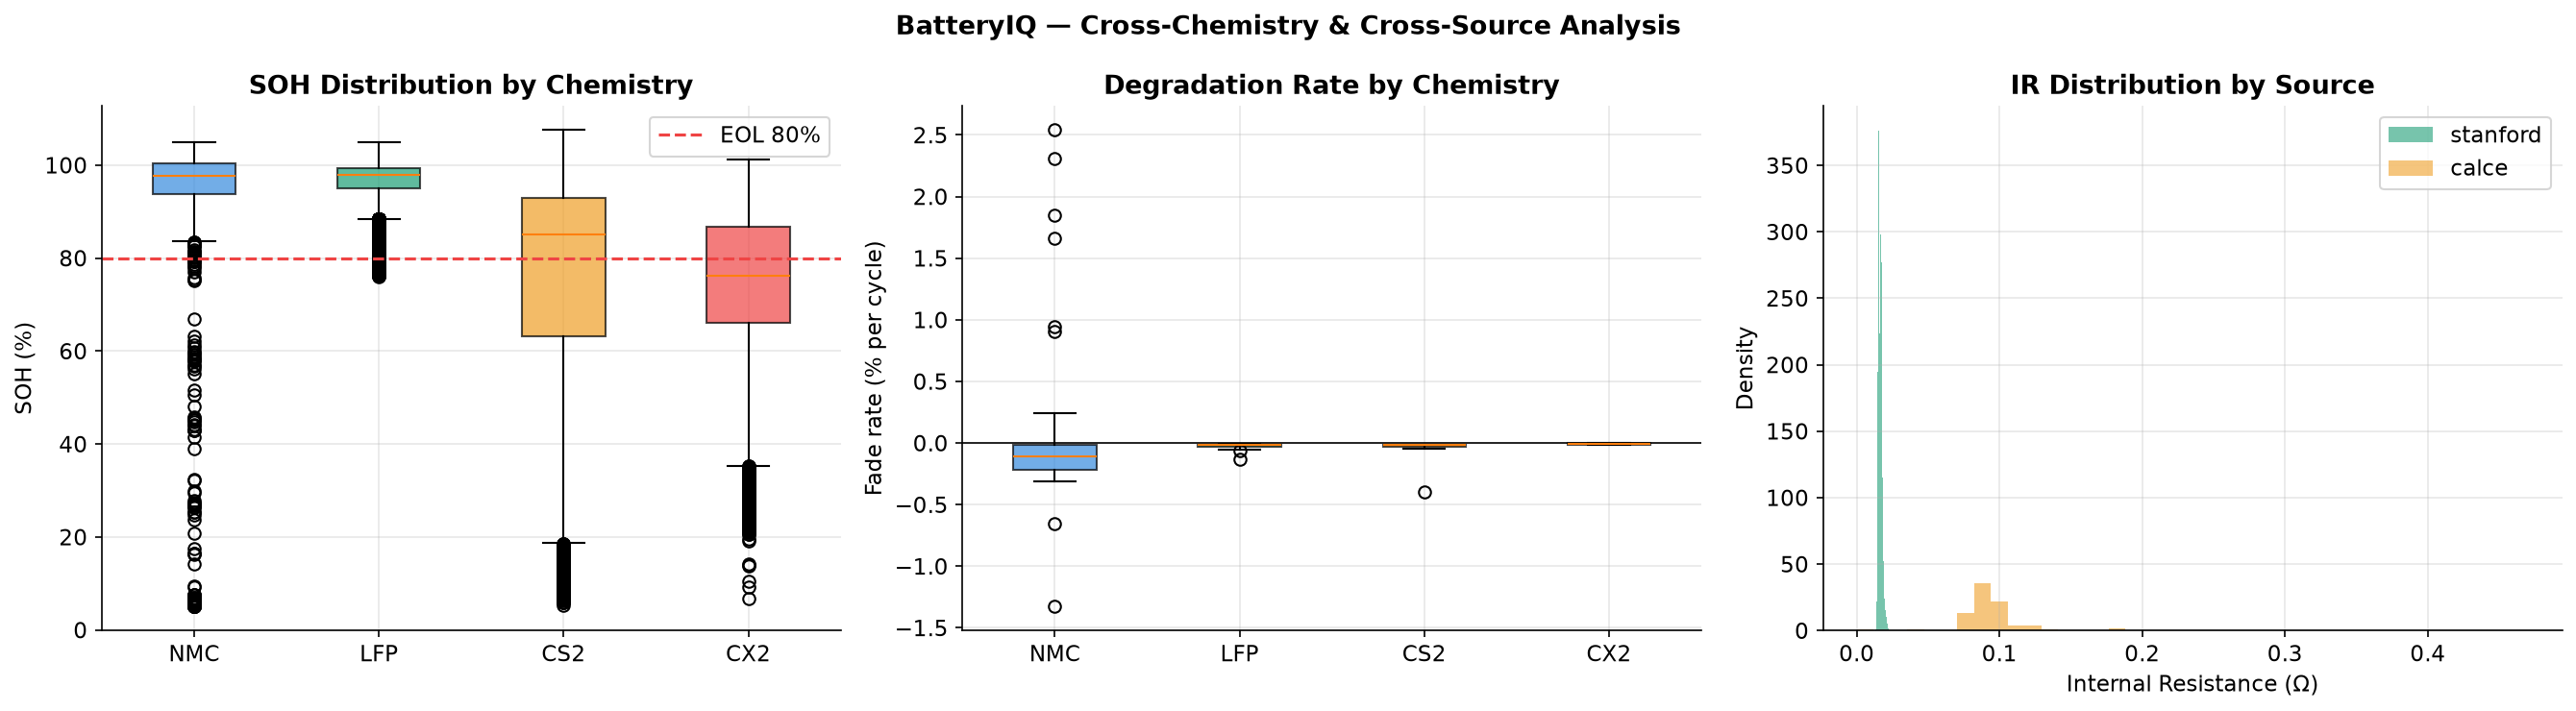

✅ Saved → fig25_combined_chemistry_comparison.png


In [5]:
# Fig 3 — Chemistry comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SOH boxplot per chemistry
chem_order = ['NMC','LFP','CS2','CX2']
chem_data  = [df[df['chemistry']==c]['soh_pct'].dropna() for c in chem_order]
bp = axes[0].boxplot(chem_data, tick_labels=chem_order,
                     patch_artist=True, notch=False)
for patch, chem in zip(bp['boxes'], chem_order):
    patch.set_facecolor(CHEM_COLORS.get(chem, '#888'))
    patch.set_alpha(0.7)
axes[0].axhline(80, color='#EF4444', linestyle='--',
                linewidth=1.5, label='EOL 80%')
axes[0].set_ylabel('SOH (%)')
axes[0].set_title('SOH Distribution by Chemistry', fontweight='bold')
axes[0].legend()

# Fade rate by chemistry
fade_rates = []
for cell, grp in df.groupby('cell_id'):
    grp = grp.sort_values('cycle_number')
    if len(grp) >= 10:
        slope = np.polyfit(grp['cycle_number'], grp['soh_pct'], 1)[0]
        fade_rates.append({
            'cell_id'  : cell,
            'source'   : grp['source'].iloc[0],
            'chemistry': grp['chemistry'].iloc[0],
            'fade_rate': slope
        })
fade_df = pd.DataFrame(fade_rates)

fade_by_chem = [fade_df[fade_df['chemistry']==c]['fade_rate'].dropna()
                for c in chem_order]
bp2 = axes[1].boxplot(fade_by_chem, tick_labels=chem_order,
                      patch_artist=True)
for patch, chem in zip(bp2['boxes'], chem_order):
    patch.set_facecolor(CHEM_COLORS.get(chem, '#888'))
    patch.set_alpha(0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Fade rate (% per cycle)')
axes[1].set_title('Degradation Rate by Chemistry', fontweight='bold')

# IR comparison across sources
ir_data = df.dropna(subset=['internal_resistance'])
for src, color in SOURCE_COLORS.items():
    data = ir_data[ir_data['source']==src]['internal_resistance']
    if len(data) > 0:
        axes[2].hist(data, bins=40, alpha=0.6,
                     color=color, edgecolor='none',
                     label=src, density=True)
axes[2].set_xlabel('Internal Resistance (Ω)')
axes[2].set_ylabel('Density')
axes[2].set_title('IR Distribution by Source', fontweight='bold')
axes[2].legend()

plt.suptitle('BatteryIQ — Cross-Chemistry & Cross-Source Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig25_combined_chemistry_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → fig25_combined_chemistry_comparison.png')

## 4. Full Correlation Analysis on Combined Dataset

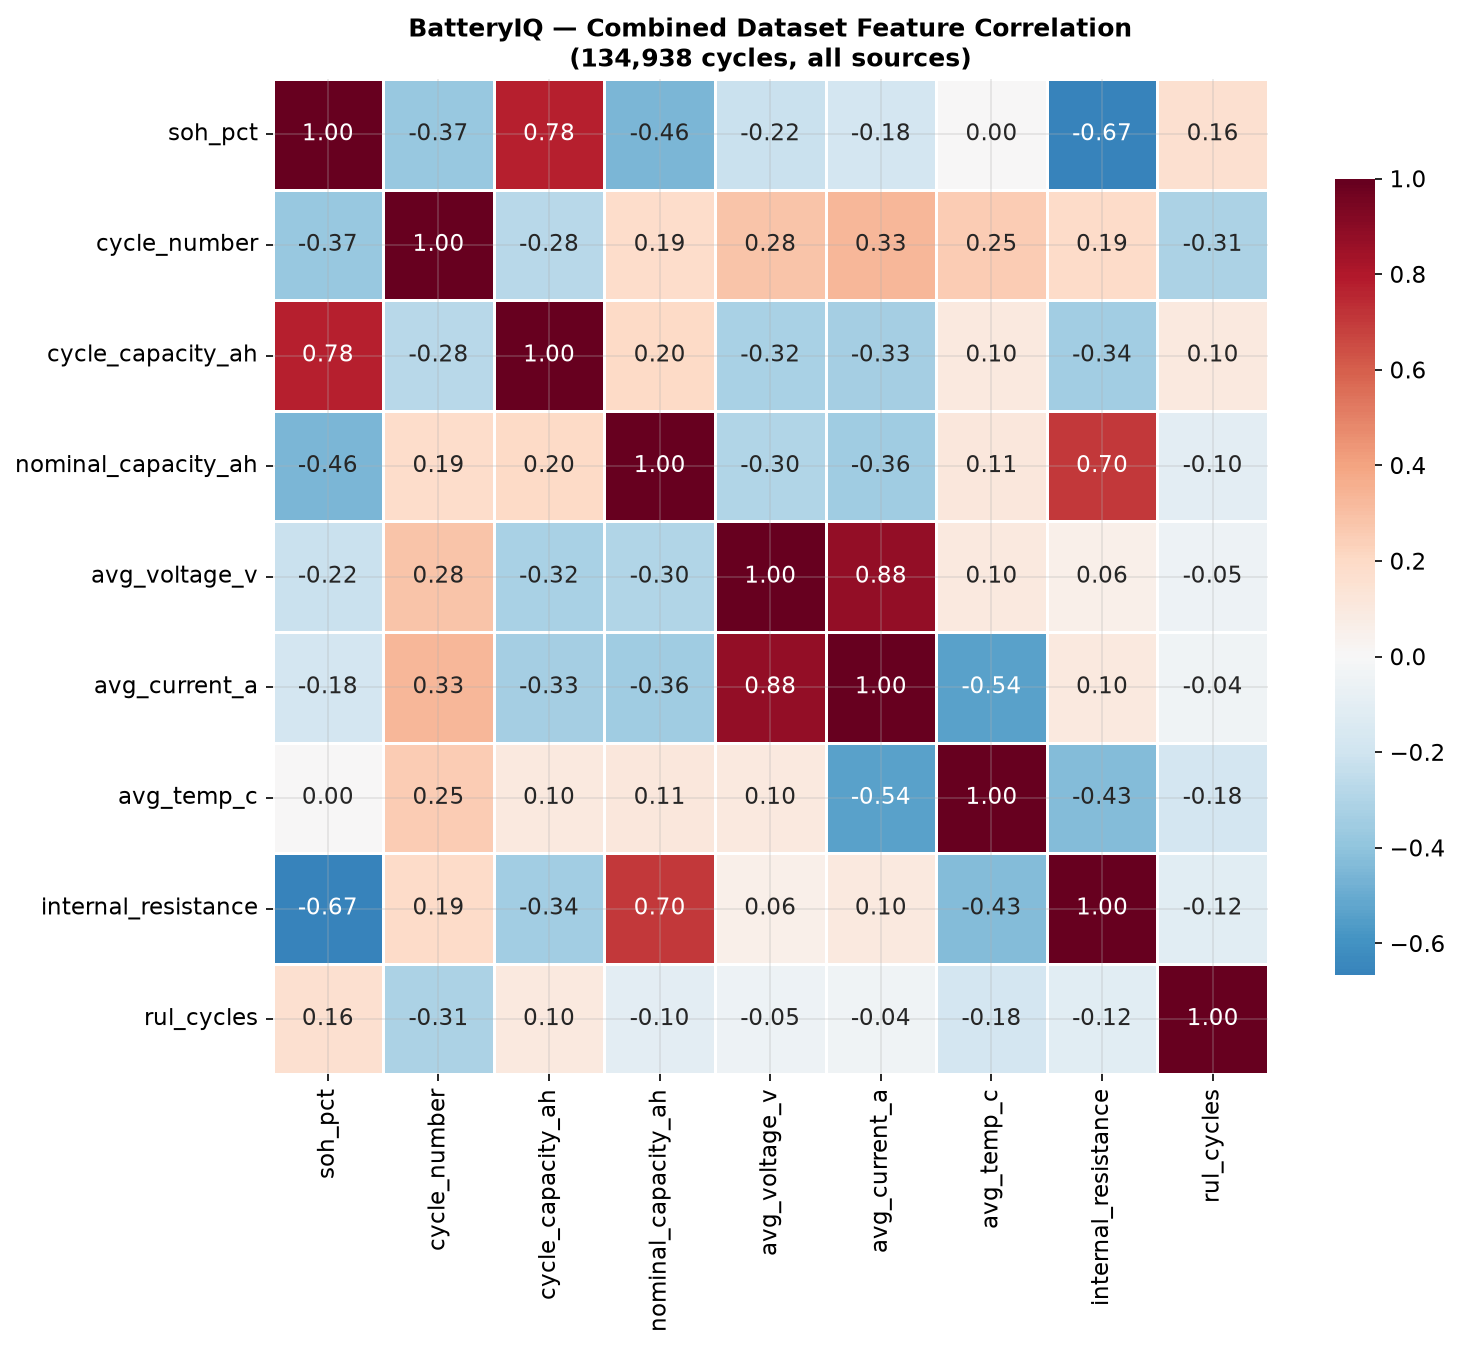

✅ Saved → fig26_combined_correlations.png

=== Top correlations with SOH (combined dataset) ===
  internal_resistance           : -0.666  █████████████
  nominal_capacity_ah           : -0.456  █████████
  cycle_number                  : -0.374  ███████
  avg_voltage_v                 : -0.222  ████
  avg_current_a                 : -0.183  ███
  avg_temp_c                    : +0.004  
  rul_cycles                    : +0.159  ███
  cycle_capacity_ah             : +0.778  ███████████████


In [6]:
# Fig 4 — Combined correlation heatmap
num_cols = ['soh_pct','cycle_number','cycle_capacity_ah',
            'nominal_capacity_ah','avg_voltage_v',
            'avg_current_a','avg_temp_c',
            'internal_resistance','rul_cycles']
num_cols = [c for c in num_cols if c in df.columns]
corr     = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
ax.set_title('BatteryIQ — Combined Dataset Feature Correlation\n(134,938 cycles, all sources)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig26_combined_correlations.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → fig26_combined_correlations.png')

print('\n=== Top correlations with SOH (combined dataset) ===')
soh_corr = corr['soh_pct'].drop('soh_pct').sort_values()
for feat, val in soh_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f'  {feat:30s}: {sign}{abs(val):.3f}  {bar}')

## 5. Missing Values Analysis

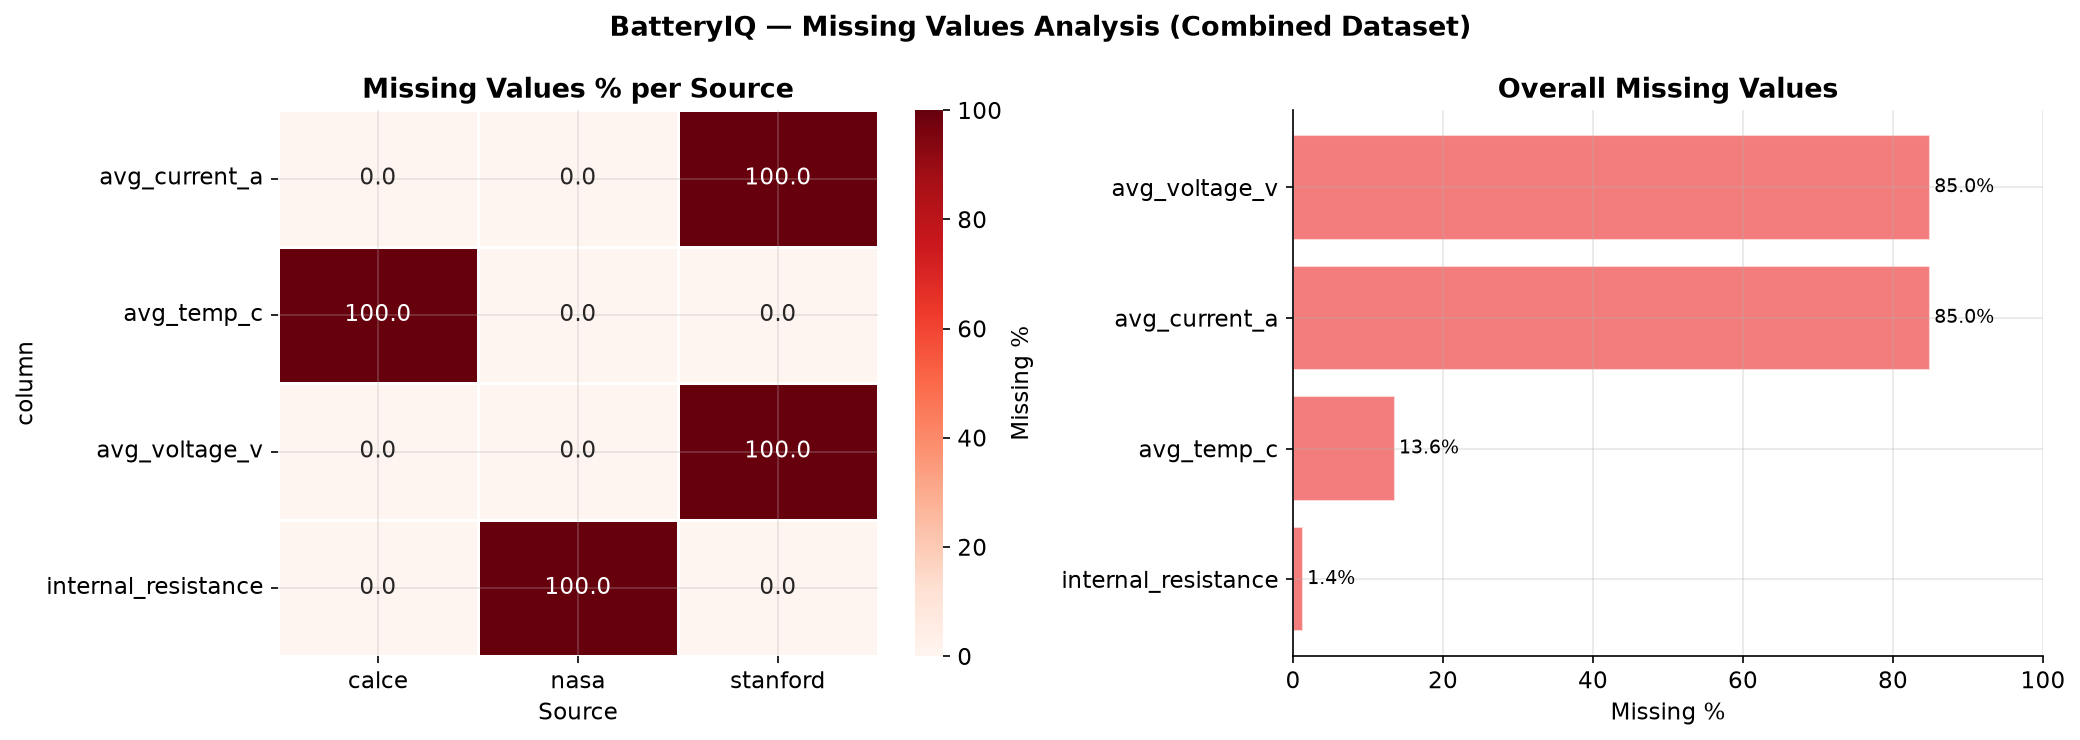

✅ Saved → fig27_combined_missing_values.png


In [7]:
# Fig 5 — Missing values heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing % per column per source
miss_data = []
for src in ['nasa','stanford','calce']:
    src_df = df[df['source']==src]
    for col in ['avg_voltage_v','avg_current_a','avg_temp_c','internal_resistance']:
        pct = src_df[col].isna().mean() * 100
        miss_data.append({'source': src, 'column': col, 'missing_pct': pct})

miss_df  = pd.DataFrame(miss_data)
miss_piv = miss_df.pivot(index='column', columns='source', values='missing_pct')

sns.heatmap(miss_piv, annot=True, fmt='.1f', cmap='Reds',
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Missing %'})
axes[0].set_title('Missing Values % per Source', fontweight='bold')
axes[0].set_xlabel('Source')

# Overall missing summary bar
overall_miss = df[num_cols].isna().mean() * 100
overall_miss = overall_miss[overall_miss > 0].sort_values(ascending=True)
axes[1].barh(overall_miss.index, overall_miss.values,
             color='#EF4444', alpha=0.7, edgecolor='white')
for i, val in enumerate(overall_miss.values):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_xlabel('Missing %')
axes[1].set_title('Overall Missing Values', fontweight='bold')
axes[1].set_xlim(0, 100)

plt.suptitle('BatteryIQ — Missing Values Analysis (Combined Dataset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig27_combined_missing_values.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → fig27_combined_missing_values.png')

## 6. Combined EDA Summary

In [8]:
print('=' * 65)
print('COMBINED EDA — KEY FINDINGS (for Chapter 4)')
print('=' * 65)

for src, grp in df.groupby('source'):
    life = grp.groupby('cell_id')['cycle_number'].max().mean()
    print(f'  {src:12s}: {len(grp):7,} cycles | '
          f'{grp["cell_id"].nunique():3d} cells | '
          f'avg life {life:.0f} cycles | '
          f'SOH {grp["soh_pct"].min():.0f}%→{grp["soh_pct"].max():.0f}%')

print(f"""
KEY CROSS-DATASET FINDINGS
  1. LFP (Stanford) has the longest cycle life ({df[df['chemistry']=='LFP'].groupby('cell_id')['cycle_number'].max().mean():.0f} avg)
     NMC (NASA) degrades faster ({df[df['chemistry']=='NMC'].groupby('cell_id')['cycle_number'].max().mean():.0f} avg cycles)
     → Chemistry is the most important factor for longevity

  2. Internal resistance is a universal degradation indicator
     → Negative correlation with SOH in ALL 3 datasets
     → Strongest PINN physics feature candidate

  3. Missing data strategy:
     → avg_voltage and avg_current: 85% missing (Stanford has no timeseries)
     → internal_resistance: only 1.4% missing → use as primary physics feature
     → avg_temp: 13.6% missing → impute with source median in feature engineering

  4. SOH distributions differ significantly across sources:
     → Stanford: 75.9%→104.8% (never goes below 76% — LFP plateau)
     → NASA: 5%→105% (full degradation range)
     → CALCE: 4.6%→107.6% (deepest degradation — most diverse)
     → Multi-source training covers the full SOH spectrum

  5. Dataset is heavily imbalanced:
     → Stanford dominates: 85% of all cycles
     → NASA: 1.4% of cycles but highest diversity in degradation
     → This imbalance must be handled in ML training (sampling strategy)

FIGURES SAVED TO memoire/figures/
  fig23_combined_master_overview.png
  fig24_combined_soh_comparison.png
  fig25_combined_chemistry_comparison.png
  fig26_combined_correlations.png
  fig27_combined_missing_values.png
""")
print('✅ Combined EDA complete!')
print('\n📊 TOTAL FIGURES FOR CHAPTER 4:')
print('   NASA EDA    : fig01 → fig09  (9 figures)')
print('   Stanford EDA: fig11 → fig17  (7 figures)')
print('   CALCE EDA   : fig18 → fig22  (5 figures)')
print('   Combined EDA: fig23 → fig27  (5 figures)')
print('   TOTAL       : 26 figures ready for Chapter 4')

COMBINED EDA — KEY FINDINGS (for Chapter 4)
  calce       :  18,379 cycles |  15 cells | avg life 1276 cycles | SOH 5%→108%
  nasa        :   1,871 cycles |  34 cells | avg life 57 cycles | SOH 5%→105%
  stanford    : 114,688 cycles | 140 cells | avg life 820 cycles | SOH 76%→105%

KEY CROSS-DATASET FINDINGS
  1. LFP (Stanford) has the longest cycle life (820 avg)
     NMC (NASA) degrades faster (57 avg cycles)
     → Chemistry is the most important factor for longevity

  2. Internal resistance is a universal degradation indicator
     → Negative correlation with SOH in ALL 3 datasets
     → Strongest PINN physics feature candidate

  3. Missing data strategy:
     → avg_voltage and avg_current: 85% missing (Stanford has no timeseries)
     → internal_resistance: only 1.4% missing → use as primary physics feature
     → avg_temp: 13.6% missing → impute with source median in feature engineering

  4. SOH distributions differ significantly across sources:
     → Stanford: 75.9%→104.8% (